# The story so far

*Status: overview. Written 2026-08-15, after E2 stage B.*

One pass through the evidence, in the order the argument runs. Every number is
read out of a committed artifact under `results/` — nothing here is retyped, so
this notebook goes stale loudly rather than quietly. The detail lives in the
four analysis notebooks and in `EXPERIMENT_LOG.md`; this is the read-first
version.

**The one-sentence claim.** Hidden-state geometry, measured as relative
Mahalanobis distance over a single forward pass, says *which problems a model
will fail* — it adds selective-prediction value on top of an eight-sample
self-consistency baseline on three models — and it does not say *which attempt
is right*. Most of what it knows is prompt difficulty.

**The shape of the paper.** A measurement-and-reframe paper, not a new
statistic. Half the contribution is a set of controls that shrink or kill prior
claims about reasoning geometry, this project's own included. The other half is
what is left standing after them.

**One half of two.** This notebook is the selective-prediction result and the
controls that bound it. The causal thread — activation patching on a synthetic
arithmetic graph — is written up on its own in
[15](15_dag_paper_story.ipynb). They share a question, not an experiment.

Details, in reading order: [12](12_wave1_abstention.ipynb) where geometry wins ·
[11](11_prompt_geometry_core_experiments.ipynb) where it does not ·
[13](13_deepconf_null_and_label_efficiency.ipynb) the baselines and the label
budget · [02](02_layer_dynamics.ipynb) the layer profile.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import fisher_exact

sys.path.insert(0, str(Path.cwd()))
import _viz_utils as vu

ROOT = vu.repo_root()

MODELS = {
    "qwen": "Qwen2.5-7B-Instruct",
    "deepseek": "DeepSeek-R1-Distill-Qwen-7B",
    "deepseek_llama": "DeepSeek-R1-Distill-Llama-8B",
}
BESTOFN = {label: f"results/{label}_bestofn_full/math500" for label in MODELS}
POPULATION = "cap_free_valid_plurality"


def load(path):
    with (ROOT / path).open(encoding="utf-8") as handle:
        return json.load(handle)


def ci(entry, digits=4):
    """point [low, high], the shape every bootstrap dict in these files uses."""
    return (
        f"{entry['point_estimate']:+.{digits}f} "
        f"[{entry['ci_low']:+.{digits}f}, {entry['ci_high']:+.{digits}f}]"
    )


INCREMENT = {
    label: load(f"{d}/math500_incremental_abstention_results.json")
    for label, d in BESTOFN.items()
}
# The solo-scorer stage never ran on the Llama distill, so this one dict is two
# models wide where the others are three.
BASELINES = {
    label: load(f"{d}/math500_abstention_baselines_results.json")
    for label, d in BESTOFN.items()
    if (ROOT / d / "math500_abstention_baselines_results.json").exists()
}
PEER = load("results/peer_difficulty_control/peer_difficulty_control_results.json")
ORGAD = load("results/orgad_agreement_control/orgad_agreement_control_results.json")
ALLOCATION = load("results/allocation_precheck/allocation_precheck_results.json")
DAG_POOLED = load("results/dag_patching/POOLED.json")
STAGE_B = load("results/dag_patching/e2_stage_b/ANALYSIS.json")["analysis"]

pd.set_option("display.width", 160)
print(f"repo root      {ROOT}")
print(f"models         {', '.join(INCREMENT)}  (solo scorers: {', '.join(BASELINES)})")
print(f"patching       pooled layer {DAG_POOLED['layer']}, stage B layer {STAGE_B['layer']}")

repo root      /home/djaniak/projects/reasoning-geometry-probe
models         qwen, deepseek, deepseek_llama  (solo scorers: qwen, deepseek)
patching       pooled layer 13, stage B layer 13


## 1. The object of study

Fit a reference manifold on hidden states from **correct** traces only — PCA to
128 dimensions, then a regularised Gaussian — and score a new trace by its
Mahalanobis distance to it, *minus* its distance to an unconditional background
Gaussian. That subtraction is the whole mechanism: raw Mahalanobis is close to
useless on reasoning traces, and going relative is worth +0.18 / +0.14 AUC.
`rmd_tail_q20` averages the per-token score over the final 20% of the trace.

The primitive is **not novel** — Vazhentsev et al. already define token-level
RMD and whole-trace ATRMD. The contribution is the evaluation.

| | |
|:--|:--|
| target | plurality-vote correctness over 8 sampled traces per prompt |
| `B0` | length, entropy, logprob, vote agreement — a self-consistency baseline |
| `B1` | `B0` + `rmd_tail_q20` |
| readout | out-of-fold logistic regression, prompt-clustered paired bootstrap, 1000 draws |
| metric | AURC, lower is better; **deltas only** across models, since levels inherit base accuracy |

Data: MATH-500, Best-of-8, three 7–8B models from two architecture families.
That is also the binding limitation — one dataset, one prompt set, two of the
three models reasoning-distilled and two Qwen-lineage.

## 2. The first control is the population

`collect_data.py` labels a trace with no parseable answer as incorrect, and
generation-capped traces dominate that class. The 2026-08-03 continuation study
says that label is wrong: capped traces resumed to 16,384 tokens **terminate 70%
[0.56, 0.81] of the time and are correct 46% of those**, against 5.6% as scored.
Capping is a budget shortfall, so those rows are censored observations, not
failures — which makes excluding them missing-data handling rather than dropping
inconvenient traces.

Everything headline below is on the cap-free population.

In [2]:
rows = []
for label, payload in INCREMENT.items():
    for name in ("full_population", POPULATION):
        pop = payload["populations"][name]
        rows.append(
            {
                "model": label,
                "population": name,
                "prompts": pop["n_prompts"],
                "capped prompts": pop["n_capped_prompts"],
                "unparsed traces": pop["n_unparsed_traces"],
                "base accuracy": round(pop["base_accuracy"], 3),
            }
        )
print(pd.DataFrame(rows).to_string(index=False))

         model               population  prompts  capped prompts  unparsed traces  base accuracy
          qwen          full_population      500             108              328          0.620
          qwen cap_free_valid_plurality      392               0                1          0.691
      deepseek          full_population      500             107              351          0.750
      deepseek cap_free_valid_plurality      393               0               15          0.796
deepseek_llama          full_population      500              92              229          0.634
deepseek_llama cap_free_valid_plurality      408               0                0          0.674


## 3. What did not survive the controls

Including several of this project's own earlier claims. This half of the paper
is the reason to trust the other half.

| Claim | Verdict |
|:--|:--|
| within-prompt geometry is "genuinely trace-level", AUC 0.93 | **retracted** — truncation artifact |
| distillation compresses correctness geometry to ~8 dimensions | **rejected** — parseable-only, DeepSeek climbs to 128 exactly like Qwen |
| the geometry effect is much stronger on DeepSeek than Qwen | **rejected** — it tracks 43% vs 8% truncation, not the model |
| the correct-reasoning manifold *shape* transfers across models | **weakened** — the readout half survives, the shape half in one direction on a weak signal |
| geometry rejects non-terminating traces | **do not say it** — length detects unparsed at 0.996 vs RMD 0.84; and it detects *unfinished*, not non-terminating |
| entropy-localised RMD is the method | **Qwen-specific** — untailed `rmd_full` recovers nearly the whole increment on both distilled models |
| one-class geometry is unusually sample-efficient | **narrowed** — see §7; it was measured against a probe differing in three ways at once |

Sources: `PAPER_STRATEGY.md` §3 and §7c, `EXPERIMENT_LOG.md` 2026-08-03 and
2026-08-09.

## 4. The headline: the increment

`B1 − B0` on the cap-free valid-plurality population. Negative favours geometry.

                       model   n  B0 AURC  B1 AURC                    B1 - B0     p
         Qwen2.5-7B-Instruct 392   0.1960   0.1375 -0.0585 [-0.1026, -0.0182] 0.004
 DeepSeek-R1-Distill-Qwen-7B 393   0.1522   0.1167 -0.0355 [-0.0642, -0.0097] 0.004
DeepSeek-R1-Distill-Llama-8B 408   0.2369   0.1808 -0.0560 [-0.0910, -0.0232] 0.000


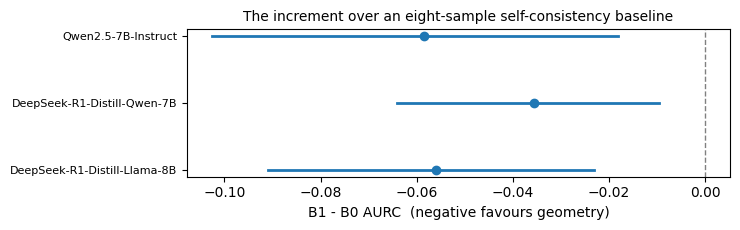

In [3]:
rows = []
for label, payload in INCREMENT.items():
    pop = payload["populations"][POPULATION]
    delta = pop["paired_deltas"]["B1_minus_B0_aurc"]
    rows.append(
        {
            "model": MODELS[label],
            "n": pop["n_prompts"],
            "B0 AURC": round(pop["models"]["B0"]["metrics"]["aurc"], 4),
            "B1 AURC": round(pop["models"]["B1"]["metrics"]["aurc"], 4),
            "B1 - B0": ci(delta),
            "p": delta["p_two_sided"],
        }
    )
print(pd.DataFrame(rows).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 2.4))
order = list(reversed(list(MODELS)))
for i, label in enumerate(order):
    d = INCREMENT[label]["populations"][POPULATION]["paired_deltas"]["B1_minus_B0_aurc"]
    ax.plot([d["ci_low"], d["ci_high"]], [i, i], color="tab:blue", lw=2)
    ax.plot([d["point_estimate"]], [i], "o", color="tab:blue")
ax.axvline(0.0, color="grey", lw=1, ls="--")
ax.set_yticks(range(len(order)))
ax.set_yticklabels([MODELS[m] for m in order], fontsize=8)
ax.set_xlabel("B1 - B0 AURC  (negative favours geometry)")
ax.set_title("The increment over an eight-sample self-consistency baseline", fontsize=10)
fig.tight_layout()
plt.show()

## 5. Geometry on its own, against the cheap scorers

One scorer at a time, no readout: accuracy among the 50% of prompts it is most
confident about. This ran on two of the three models.

`length` is the baseline to watch — it is deceptively strong and prior
geometry/UQ work rarely benchmarks against it standalone.

accuracy at 50% coverage, single scorer, all 500 prompts
   model  prompts  rmd_tail_q20  vote_agreement  length  logprob  entropy  conf_bottom10_group_ent
    qwen      500         0.852           0.732   0.748    0.704    0.692                    0.696
deepseek      500         0.856           0.784   0.828    0.788    0.792                    0.772


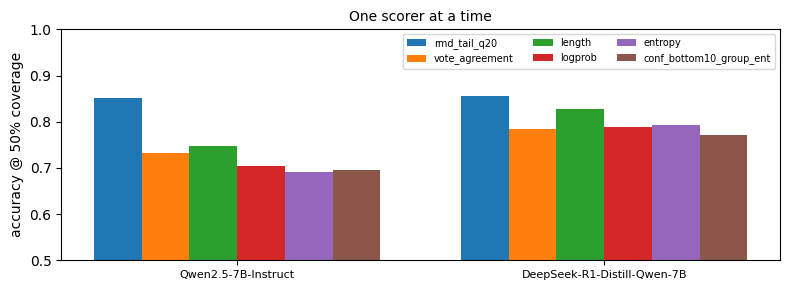

In [4]:
SOLO = ["rmd_tail_q20", "vote_agreement", "length", "logprob", "entropy",
        "conf_bottom10_group_ent"]
rows = []
for label, payload in BASELINES.items():
    point = payload["abstention"]["point"]
    row = {"model": label, "prompts": payload["abstention"]["n_prompts"]}
    row.update({m: round(point[m]["accuracy_at_coverage"]["0.5"], 3) for m in SOLO})
    rows.append(row)
solo = pd.DataFrame(rows)
print("accuracy at 50% coverage, single scorer, all 500 prompts")
print(solo.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.0))
width = 0.13
for i, method in enumerate(SOLO):
    ax.bar([j + i * width for j in range(len(solo))], solo[method], width=width, label=method)
ax.set_xticks([j + width * (len(SOLO) - 1) / 2 for j in range(len(solo))])
ax.set_xticklabels([MODELS[m] for m in solo["model"]], fontsize=8)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("accuracy @ 50% coverage")
ax.legend(fontsize=7, ncol=3)
ax.set_title("One scorer at a time", fontsize=10)
fig.tight_layout()
plt.show()

## 6. Four controls the increment survives

**A. Length.** Partial trace length out of both scorers in rank space, then
compare against an uninformative scorer. Geometry keeps a large length-
independent component; on the reasoning-distilled model the *output-side*
baselines are the ones that turn out to be length proxies.

**B. DeepConf** (arXiv:2508.15260) as a prompt-level score, with all four of its
statistics. It is at chance on both models in all three framings, so there is no
external confidence baseline left to beat.

**C. The vote-proxy objection** (Orgad et al., arXiv:2410.02707): is geometry
just reading self-consistency? Inside the stratum where all eight siblings agree
and self-consistency is silent by construction, geometry still ranks.

**D. Difficulty.** Hand each model's `B0` the *other two models'* eight-sibling
pass rates — an empirical difficulty signal the target model did not produce.
This is the control that bites.

In [5]:
print("A. length partialled out of both sides, vs an uninformative scorer (AUACC)")
rows = []
for label, payload in BASELINES.items():
    vs = payload["length_residualized"]["vs_uninformative"]
    rows.append(
        {
            "model": label,
            "rmd_tail_q20": ci(vs["rmd_tail_q20"]["auacc"], 3),
            "entropy": ci(vs["entropy"]["auacc"], 3),
            "logprob": ci(vs["logprob"]["auacc"], 3),
        }
    )
print(pd.DataFrame(rows).to_string(index=False))

print("\nB. geometry minus DeepConf's own statistic (accuracy @ 50% coverage)")
rows = []
for label, payload in BASELINES.items():
    deltas = payload["abstention"]["deltas"]
    rows.append(
        {
            "model": label,
            "vs bottom-10% group": ci(deltas["rmd_tail_q20_minus_conf_bottom10_group_ent"]["0.5"], 3),
            "vs tail entropy": ci(deltas["rmd_tail_q20_minus_conf_tail_q20_ent"]["0.5"], 3),
            "vs vote agreement": ci(deltas["rmd_tail_q20_minus_vote_agreement"]["0.5"], 3),
        }
    )
print(pd.DataFrame(rows).to_string(index=False))

print("\nC. inside the stratum where all eight siblings agree (AUROC)")
rows = []
for entry in ORGAD:
    unanimous = entry["strata"]["unanimous"]
    rows.append(
        {
            "model": entry["label"],
            "prompts": entry["n_prompts"],
            "unanimous": unanimous["n_prompts"],
            "share": round(unanimous["n_prompts"] / entry["n_prompts"], 2),
            "geometry AUROC there": ci(unanimous["auroc"], 3),
        }
    )
print(pd.DataFrame(rows).to_string(index=False))

print("\nD. peer-model pass rates inside the readout (AURC)")
rows = []
for entry in PEER["models"]:
    deltas = entry["populations"][POPULATION]["paired_deltas"]
    rows.append(
        {
            "model": entry["label"],
            "B1 - B0": ci(deltas["B1_minus_B0_aurc"]),
            "B1 - B0 | peer": ci(deltas["B1_minus_B0_given_peer_aurc"]),
            "peer - B0": ci(deltas["peer_minus_B0_aurc"]),
            "Holm p": PEER["holm"]["tests"][entry["label"]]["p_holm"],
        }
    )
print(pd.DataFrame(rows).to_string(index=False))
print("pre-declared stop rule triggered:", PEER["stop_rule"]["triggered"])

A. length partialled out of both sides, vs an uninformative scorer (AUACC)
   model            rmd_tail_q20                 entropy                 logprob
    qwen +0.161 [+0.126, +0.194] +0.057 [+0.017, +0.096] +0.058 [+0.017, +0.096]
deepseek +0.107 [+0.076, +0.135] +0.011 [-0.029, +0.046] +0.009 [-0.030, +0.046]

B. geometry minus DeepConf's own statistic (accuracy @ 50% coverage)
   model     vs bottom-10% group         vs tail entropy       vs vote agreement
    qwen +0.156 [+0.096, +0.208] +0.172 [+0.124, +0.236] +0.120 [+0.076, +0.172]
deepseek +0.084 [+0.036, +0.132] +0.076 [+0.032, +0.124] +0.072 [+0.008, +0.112]

C. inside the stratum where all eight siblings agree (AUROC)
        model  prompts  unanimous  share    geometry AUROC there
DeepSeek-Qwen      393        349   0.89 +0.714 [+0.648, +0.784]
        Llama      408        214   0.52 +0.756 [+0.685, +0.830]
         Qwen      392        274   0.70 +0.829 [+0.771, +0.884]

D. peer-model pass rates inside the readout (A

### Reading D honestly

The peer control is the first difficulty control here that beats `B0` on its own
— it cuts AURC by 28–82% where the two earlier ones were worth zero or less.
Against it the increment shrinks about **fivefold** and clears zero on two of
three models; Holm over the pre-declared family of three passes one.

DeepSeek-R1-Distill-Qwen-7B's null is a **ceiling, not redundancy**: with the
peer control its readout lands 0.0045 above a perfect ranker's AURC, leaving
nothing for any feature to remove.

So: **most of the increment is prompt difficulty.** That is a claim about the
mechanism, not a defeat — peer pass rates do not exist at decision time, so this
is a control the method is not required to beat. But the paper must say it in
the abstract, not the appendix.

## 7. The boundary — four things geometry does not do

- **Within-prompt correctness.** A pre-registered cross-model gate failed
  (2026-07-29): the localisation effect is +0.004 [−0.016, +0.027] on
  DeepSeek-R1-Distill-Qwen-7B against Qwen's +0.058, and *every* within-prompt
  AUC on that model — geometry and output baselines alike — sits at or below
  chance. Geometry indicates which problems are hard, not which attempt is right.
- **Best-of-N reranking.** Closed with a structural explanation: at N=8 only
  39/500 prompts tie and ~10 have headroom, a ~2-point ceiling; every tie-break
  delta is ≤0.006, p ≥ 0.248.
- **Label efficiency at scale.** The 50-label gap against a pooling-matched
  linear probe is −0.033 AURC, and the ladder splits it into −0.011 supervision
  + −0.018 decision-function *form*. Both rungs expire by 100 labels. The
  defensible sentence is that a positive-only fit is a cheap way to get a
  quadratic decision function, and the quadratic is where the advantage lives.
- **Sample allocation.** A pre-declared gate asked whether single-trace geometry
  predicts the gain from buying more samples, `g(p) = a(p,8) − a(p,1)`:

In [6]:
print("target:", ALLOCATION["target"])
rows = []
for entry in ALLOCATION["models"]:
    across = entry["across_draws"]
    summary = entry["gain_summary"]
    rows.append(
        {
            "model": entry["label"],
            "share of prompts with zero gain": round(summary["share_exactly_zero"], 3),
            "rho(pass rate, gain)": round(summary["spearman_pass_rate_vs_gain"], 3),
            "geometry rank-corr with gain": round(across["spearman"]["geometry"]["median"], 3),
            "geometry R^2 on gain": round(across["r2_vs_constant"]["geometry"]["median"], 4),
            "geometry AUROC on difficulty": round(across["auroc_vs_prompt_outcome"]["median"], 3),
            "passes": ALLOCATION["gate"]["per_model"][entry["label"]]["passes"],
        }
    )
print(pd.DataFrame(rows).to_string(index=False))
print("\ngate:", ALLOCATION["gate"]["passes"], "|", ALLOCATION["gate"]["consequence"])

target: g(p) = a(p,8) - a(p,1), where a(p,k) is the expected plurality-vote correctness over all C(8,k) sibling subsets
         model  share of prompts with zero gain  rho(pass rate, gain)  geometry rank-corr with gain  geometry R^2 on gain  geometry AUROC on difficulty  passes
          qwen                            0.791                -0.090                        -0.042               -0.0037                         0.790   False
      deepseek                            0.896                -0.161                        -0.057               -0.0065                         0.674   False
deepseek_llama                            0.679                -0.035                        -0.074                0.0005                         0.688    True

gate: False | step 3 is not run; geometry contributes nothing to allocation and that is the finding


Geometry ranks the gain **backwards** on all three models while correlating
+0.51 / +0.24 / +0.37 with the pass rate. The one nominal pass sits at
R² = +0.0005 and is a coin flip; do not read 1 of 3 as partial support. The
target is also mostly zero — a prompt at 0/8 and one at 8/8 both gain nothing —
so nothing else predicts `g` either. Allocation is **closed**, not pending.
Routing and abstention by predicted difficulty are untouched, and the same
precheck supports them at one trace (AUROC 0.790 / 0.674 / 0.688).

## 8. Where this leaves the paper

**Standing claims.**

1. On MATH-500 after eight sampled traces, trace-mean relative Mahalanobis
   distance improves prompt-level selective prediction beyond length, entropy,
   log-probability, plurality agreement, and DeepConf, on three 7–8B models from
   two architecture families.
2. Most of that increment is prompt difficulty: peer-model pass rates absorb
   roughly four fifths of it, and one model's residual is a ceiling rather than
   a null.
3. The signal is **between-prompt**, not within-prompt — abstention and routing,
   not reranking or allocation.
4. The methodological half: length, generation caps, parse failures, layer
   selection, weak difficulty controls, and fixed-prediction uncertainty each
   inflate claims about reasoning geometry, demonstrated on claims this project
   itself made.
5. A separate, small, causal result ([15](15_dag_paper_story.ipynb)): on a
   synthetic arithmetic family, an ancestor-position residual patch installs the
   implied answer when the answer reads the patched node directly and not when
   one written intermediate stands in between, and that contrast survives a
   pre-registered match on clean confidence and token distance (24/24 vs 0/24).

**Open, in priority order.** Breadth is the binding constraint and it is now
*single-dataset* scope, not model count: OlympiadBench as a second prompt set,
and a second non-distilled model so "distilled vs not" stops being confounded
with "Qwen vs not". Both are queued and neither has run. On the mechanism side,
layer 13 needs re-searching on a family it was not chosen from, the cross-item
row kind is untested on matched items, and depth 3 and the omission arms are
untouched.

**How to falsify the headline.** Run the peer-difficulty control on a fourth
model and find the residual gone; or find a single dataset where `rmd_full` does
not clear length. Neither has been tried.